# Assignment 1: Implement Gaussian Mixture Model (GMM)

In this task, you are required to implement the GMM algorithm from scratch and apply it to the FIFA 23 Players Dataset and the EastWestAirlines Dataset for clustering. You should evaluate the performance of your clustering results using both qualitative and quantitative measures.

## Datasets
* **FIFA 23 Players Dataset**: This dataset contains detailed attributes of professional soccer players. The objective is to cluster players based on their skills and playing styles. Relevant features for clustering include:
  * Age
  * Overall rating (general skill level)
  * Potential (maximum projected skill level)
  * Value (market price in €)
  * Wage (weekly salary)
  * Shooting, Passing, Dribbling (technical abilities)
  * Defending, Physicality (defensive capabilities)

  You can download the dataset from Kaggle [FIFA 23 Dataset - Kaggle](https://www.kaggle.com/datasets/bryanb/fifa-player-stats-database?select=FIFA23_official_data.csv)

* **EastWestAirlines Dataset**: This dataset contains information about airline customers and their behaviors. You should preprocess the dataset as necessary before applying the clustering algorithm.

## Tasks

1. Implement the Gaussian Mixture Model algorithm from scratch. Do not use libraries like scikit-learn's GMM implementation for this part.
2. Fit the GMM to both datasets (FIFA 23 Players and EastWestAirlines) and perform clustering.
3. Evaluate your clustering results using the following methods:
   * **Rand Index**: Calculate the Rand Index to compare your clustering results against meaningful labels (e.g., player positions). Read more about the Rand Index here: [Rand Index - Wikipedia](https://en.wikipedia.org/wiki/Rand_index).
   * **Qualitative Evaluation**: For both datasets, visualize and describe the resulting clusters (e.g., scatter plots, pair plots, or other visualizations that highlight the formed groups). For visualizations in Python, you may refer to this guide: [Seaborn Visualization Library](https://seaborn.pydata.org/).

## Hints and Useful Links

* For a detailed explanation on how Gaussian Mixture Models work and how to implement them, see this tutorial: [Gaussian Mixture Model - scikit-learn documentation](https://scikit-learn.org/stable/modules/mixture.html).
* To understand the mathematical background and principles behind GMM, this reference may help: [Mixture Model - Wikipedia](https://en.wikipedia.org/wiki/Mixture_model).

## Solution

> **Note** </br>
> The solution will be described in spanish.

### 1. Librerias y configuraciones previas

In [154]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import multivariate_normal
from sklearn.metrics import rand_score
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

### 2. Funciones

A continuación se colocan las funciones suministradas por el profesor.

In [155]:
# Function to generate a positive definite covariance matrix
def generate_positive_definite_matrix(d):
    A = np.random.randn(d, d)
    return np.dot(A, A.T) + np.eye(d) * epsilon  # Add identity for stability

# Ensure covariance matrix is positive definite
def ensure_positive_definite(Sigma):
    return Sigma + np.eye(Sigma.shape[0]) * epsilon

# Expectation Step (E-step)
def expectation_step(X, mu, Sigma, pi):
    """ Compute responsibilities (γ) given current parameters. """
    gamma = np.zeros((n, K))
    for k in range(K):
        try:
            gamma[:, k] = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=ensure_positive_definite(Sigma[k]))
        except np.linalg.LinAlgError:
            print(f"Warning: Fixing singular covariance matrix for cluster {k}")
            Sigma[k] = ensure_positive_definite(Sigma[k])
            gamma[:, k] = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=Sigma[k])

    gamma += epsilon  # Prevents division by zero
    gamma /= gamma.sum(axis=1, keepdims=True)  # Normalize
    return gamma

# Maximization Step (M-step)
def maximization_step(X, gamma):
    """ Update parameters based on responsibilities. """
    Nk = gamma.sum(axis=0)  # Effective cluster size
    pi_new = Nk / n  # Update mixing coefficients
    mu_new = np.dot(gamma.T, X) / Nk[:, np.newaxis]  # Update means

    Sigma_new = np.zeros((K, d, d))
    for k in range(K):
        X_centered = X - mu_new[k]
        Sigma_new[k] = np.dot(gamma[:, k] * X_centered.T, X_centered) / Nk[k]
        Sigma_new[k] = ensure_positive_definite(Sigma_new[k])  # Ensure positive definiteness

    return pi_new, mu_new, Sigma_new

# Compute Log-Likelihood
def compute_log_likelihood(X, pi, mu, Sigma):
    """ Compute the Log-Likelihood to monitor convergence. """
    log_likelihood = 0
    for k in range(K):
        try:
            prob = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=ensure_positive_definite(Sigma[k]))
            prob += epsilon  # Prevents log(0)
            log_likelihood += np.sum(np.log(prob))
        except np.linalg.LinAlgError:
            print(f"Warning: Fixing covariance matrix for cluster {k}")
            Sigma[k] = ensure_positive_definite(Sigma[k])
            prob = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=Sigma[k]) + epsilon
            log_likelihood += np.sum(np.log(prob))

    return log_likelihood

# Codigo del profe reescrito con la ayuda de Skynet
def expectation_maximization(X_norm, mu, Sigma, pi, max_iters=200, tol=1e-4):
    """
    Implementa el algoritmo de Expectation-Maximization (EM) con manejo de problemas numéricos.

    Parámetros:
    - X_norm: Datos de entrada normalizados.
    - mu: Medias iniciales de las distribuciones.
    - Sigma: Matrices de covarianza iniciales.
    - pi: Pesos iniciales de las componentes.
    - max_iters: Número máximo de iteraciones (default: 200).
    - tol: Umbral de convergencia para la diferencia del log-verosimilitud (default: 1e-4).

    Retorna:
    - pi: Pesos finales de las componentes.
    - mu: Medias finales de las distribuciones.
    - Sigma: Matrices de covarianza finales.
    - gamma: Matriz de responsabilidades finales.
    - log_likelihoods: Lista con la evolución del log-verosimilitud.
    """
    log_likelihoods = []
    prev_log_likelihood = -np.inf  # Inicializar con un valor muy bajo
    gamma = None  # Inicializar gamma fuera del bucle

    for i in range(max_iters):
        gamma = expectation_step(X_norm, mu, Sigma, pi)

        # Verificación de NaN o valores no válidos en gamma
        if np.isnan(gamma).any() or np.isinf(gamma).any():
            print("Se detectaron valores NaN en la matriz de responsabilidades. Deteniendo EM.")
            break

        pi, mu, Sigma = maximization_step(X_norm, gamma)

        # Evitar matrices de covarianza singulares
        for j in range(len(Sigma)):
            if np.linalg.det(Sigma[j]) == 0:
                print(f"Advertencia: Covarianza singular en la componente {j}. Ajustando...")
                Sigma[j] += np.eye(Sigma[j].shape[0]) * 1e-6  # Agregar regularización

        # Calcular log-verosimilitud
        log_likelihood = compute_log_likelihood(X_norm, pi, mu, Sigma)

        # Verificación de NaN o valores no válidos en log-likelihood
        if np.isnan(log_likelihood) or np.isinf(log_likelihood):
            print("Se detectaron valores NaN o Inf en el log-verosimilitud. Deteniendo EM.")
            break

        log_likelihoods.append(log_likelihood)
        print(f"Iteración {i+1}, Log-Verosimilitud: {log_likelihood:.4f}")

        # Verificar convergencia
        if np.abs(log_likelihood - prev_log_likelihood) < tol:
            print(f"Convergencia alcanzada en la iteración {i+1}.")
            break

        prev_log_likelihood = log_likelihood

    # Graficar evolución del log-verosimilitud
    if len(log_likelihoods) > 1:
        plt.plot(log_likelihoods)
        plt.xlabel('Iteraciones')
        plt.ylabel('Log-Verosimilitud')
        plt.title('Convergencia del Log-Verosimilitud en el Algoritmo EM')
        plt.show()

    return pi, mu, Sigma, gamma, log_likelihoods

### 3. Dataset Fifa 23

#### 3.1. Carga de datos

In [156]:
# Se carga el dataset
csv_file = 'FIFA23_official_data.csv'
df_players = pd.read_csv(csv_file)
df_players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17660 entries, 0 to 17659
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        17660 non-null  int64  
 1   Name                      17660 non-null  object 
 2   Age                       17660 non-null  int64  
 3   Photo                     17660 non-null  object 
 4   Nationality               17660 non-null  object 
 5   Flag                      17660 non-null  object 
 6   Overall                   17660 non-null  int64  
 7   Potential                 17660 non-null  int64  
 8   Club                      17449 non-null  object 
 9   Club Logo                 17660 non-null  object 
 10  Value                     17660 non-null  object 
 11  Wage                      17660 non-null  object 
 12  Special                   17660 non-null  int64  
 13  Preferred Foot            17660 non-null  object 
 14  Intern

In [157]:
(f,c) = df_players.shape
print(f"El numero de filas en el dataset es de {f}") # Filas
print(f"El numero de columnas en el dataset es de {c}") # Columnas

El numero de filas en el dataset es de 17660
El numero de columnas en el dataset es de 29


Se renombran las columnas

In [158]:
df_players.columns = df_players.columns.str.replace(' ', '_')
df_players.columns = df_players.columns.str.lower()
df_players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17660 entries, 0 to 17659
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        17660 non-null  int64  
 1   name                      17660 non-null  object 
 2   age                       17660 non-null  int64  
 3   photo                     17660 non-null  object 
 4   nationality               17660 non-null  object 
 5   flag                      17660 non-null  object 
 6   overall                   17660 non-null  int64  
 7   potential                 17660 non-null  int64  
 8   club                      17449 non-null  object 
 9   club_logo                 17660 non-null  object 
 10  value                     17660 non-null  object 
 11  wage                      17660 non-null  object 
 12  special                   17660 non-null  int64  
 13  preferred_foot            17660 non-null  object 
 14  intern

##### Variables categoricas

In [159]:
# Columnas categoricas
player_catCols = df_players.select_dtypes(include = ["object", 'category']).columns.tolist()
df_players[player_catCols].head(2)

,name,photo,nationality,flag,club,club_logo,value,wage,preferred_foot,work_rate,body_type,real_face,position,joined,loaned_from,contract_valid_until,height,weight,release_clause,best_overall_rating
0,L. Goretzka,https://cdn.sofifa.net/players/209/658/23_60.png,Germany,https://cdn.sofifa.net/flags/de.png,FC Bayern München,https://cdn.sofifa.net/teams/21/30.png,€91M,€115K,Right,High/ Medium,Unique,Yes,"<span class=""pos pos28"">SUB","Jul 1, 2018",NaN,2026,189cm,82kg,€157M,NaN
1,Bruno Fernandes,https://cdn.sofifa.net/players/212/198/23_60.png,Portugal,https://cdn.sofifa.net/flags/pt.png,Manchester United,https://cdn.sofifa.net/teams/11/30.png,€78.5M,€190K,Right,High/ High,Unique,Yes,"<span class=""pos pos15"">LCM","Jan 30, 2020",NaN,2026,179cm,69kg,€155M,NaN


Si observamos, hay varias columnas que no son de utilidad, por ejemplo **`photo`** y **`body_type`** por citar algunas. Sin embargo, vemos que otras como **`value`** y **`wage`** tienen que ver con dinero y consideramos que son datos relevantes.

Ahora veamos la cantidad de valores unicos por categoria:

In [160]:
cantidad_valores_cat_unicos = df_players[player_catCols].nunique()
print(cantidad_valores_cat_unicos)

name                    17140
photo                   17660
nationality               161
flag                      161
club                      926
club_logo                 970
value                     258
wage                      135
preferred_foot              2
work_rate                  10
body_type                  10
real_face                   2
position                   29
joined                   1855
loaned_from               270
contract_valid_until       48
height                     51
weight                     58
release_clause           1288
best_overall_rating        14
dtype: int64


##### Variables numericas

In [161]:
# Columnas numericas
player_numCols = df_players.select_dtypes(include = ['float64','int32','int64']).columns.tolist()
df_players[player_numCols].head(2)

,id,age,overall,potential,special,international_reputation,weak_foot,skill_moves,kit_number
0,209658,27,87,88,2312,4.0,4.0,3.0,8.0
1,212198,27,86,87,2305,3.0,3.0,4.0,8.0


Ahora miremos la cantidad de valores numericos unicos por caracteristica.

In [162]:
cantidad_valores_num_unicos = df_players[player_numCols].nunique()
print(cantidad_valores_num_unicos)

id                          17660
age                            31
overall                        49
potential                      50
special                      1428
international_reputation        5
weak_foot                       5
skill_moves                     5
kit_number                     99
dtype: int64


De las variables númericas vistas que no aportan a nuestro conceptos son: **`id`** asi que de entrada la quitamos.

In [163]:
player_numCols.remove('id')

Veamos un poco mas de información estadistica de los datos numericos restantes:

In [164]:
df_players[player_numCols].describe()

,age,overall,potential,special,international_reputation,weak_foot,skill_moves,kit_number
count,17660.000000,17660.000000,17660.000000,17660.000000,17660.000000,17660.000000,17660.000000,17625.000000
mean,23.127746,63.369592,70.981200,1537.915855,1.106285,2.900340,2.297169,25.037957
std,4.639821,8.036268,6.529836,285.893809,0.407021,0.663523,0.754264,19.154116
min,15.000000,43.000000,42.000000,749.000000,1.000000,1.000000,1.000000,1.000000
25%,20.000000,58.000000,67.000000,1387.000000,1.000000,3.000000,2.000000,11.000000
50%,22.000000,63.000000,71.000000,1548.000000,1.000000,3.000000,2.000000,22.000000
75%,26.000000,69.000000,75.000000,1727.000000,1.000000,3.000000,3.000000,32.000000
max,54.000000,91.000000,95.000000,2312.000000,5.000000,5.000000,5.000000,99.000000


Miremos ahora la cantidad de datos diferentes en cada columna numerica:

In [165]:
cantidad_valores_num_unicos = df_players[player_numCols].nunique()
print(cantidad_valores_num_unicos)

age                           31
overall                       49
potential                     50
special                     1428
international_reputation       5
weak_foot                      5
skill_moves                    5
kit_number                    99
dtype: int64


Segun los resultados anteriores, las caracteristicas pese a ser numericas **`international_reputation`**, **`weak_foot`**, **`skill_moves`** se presumen categoricas. Para tener una mayor perspectiva se visualizaran de manera rapida los datos mediante un pairplot

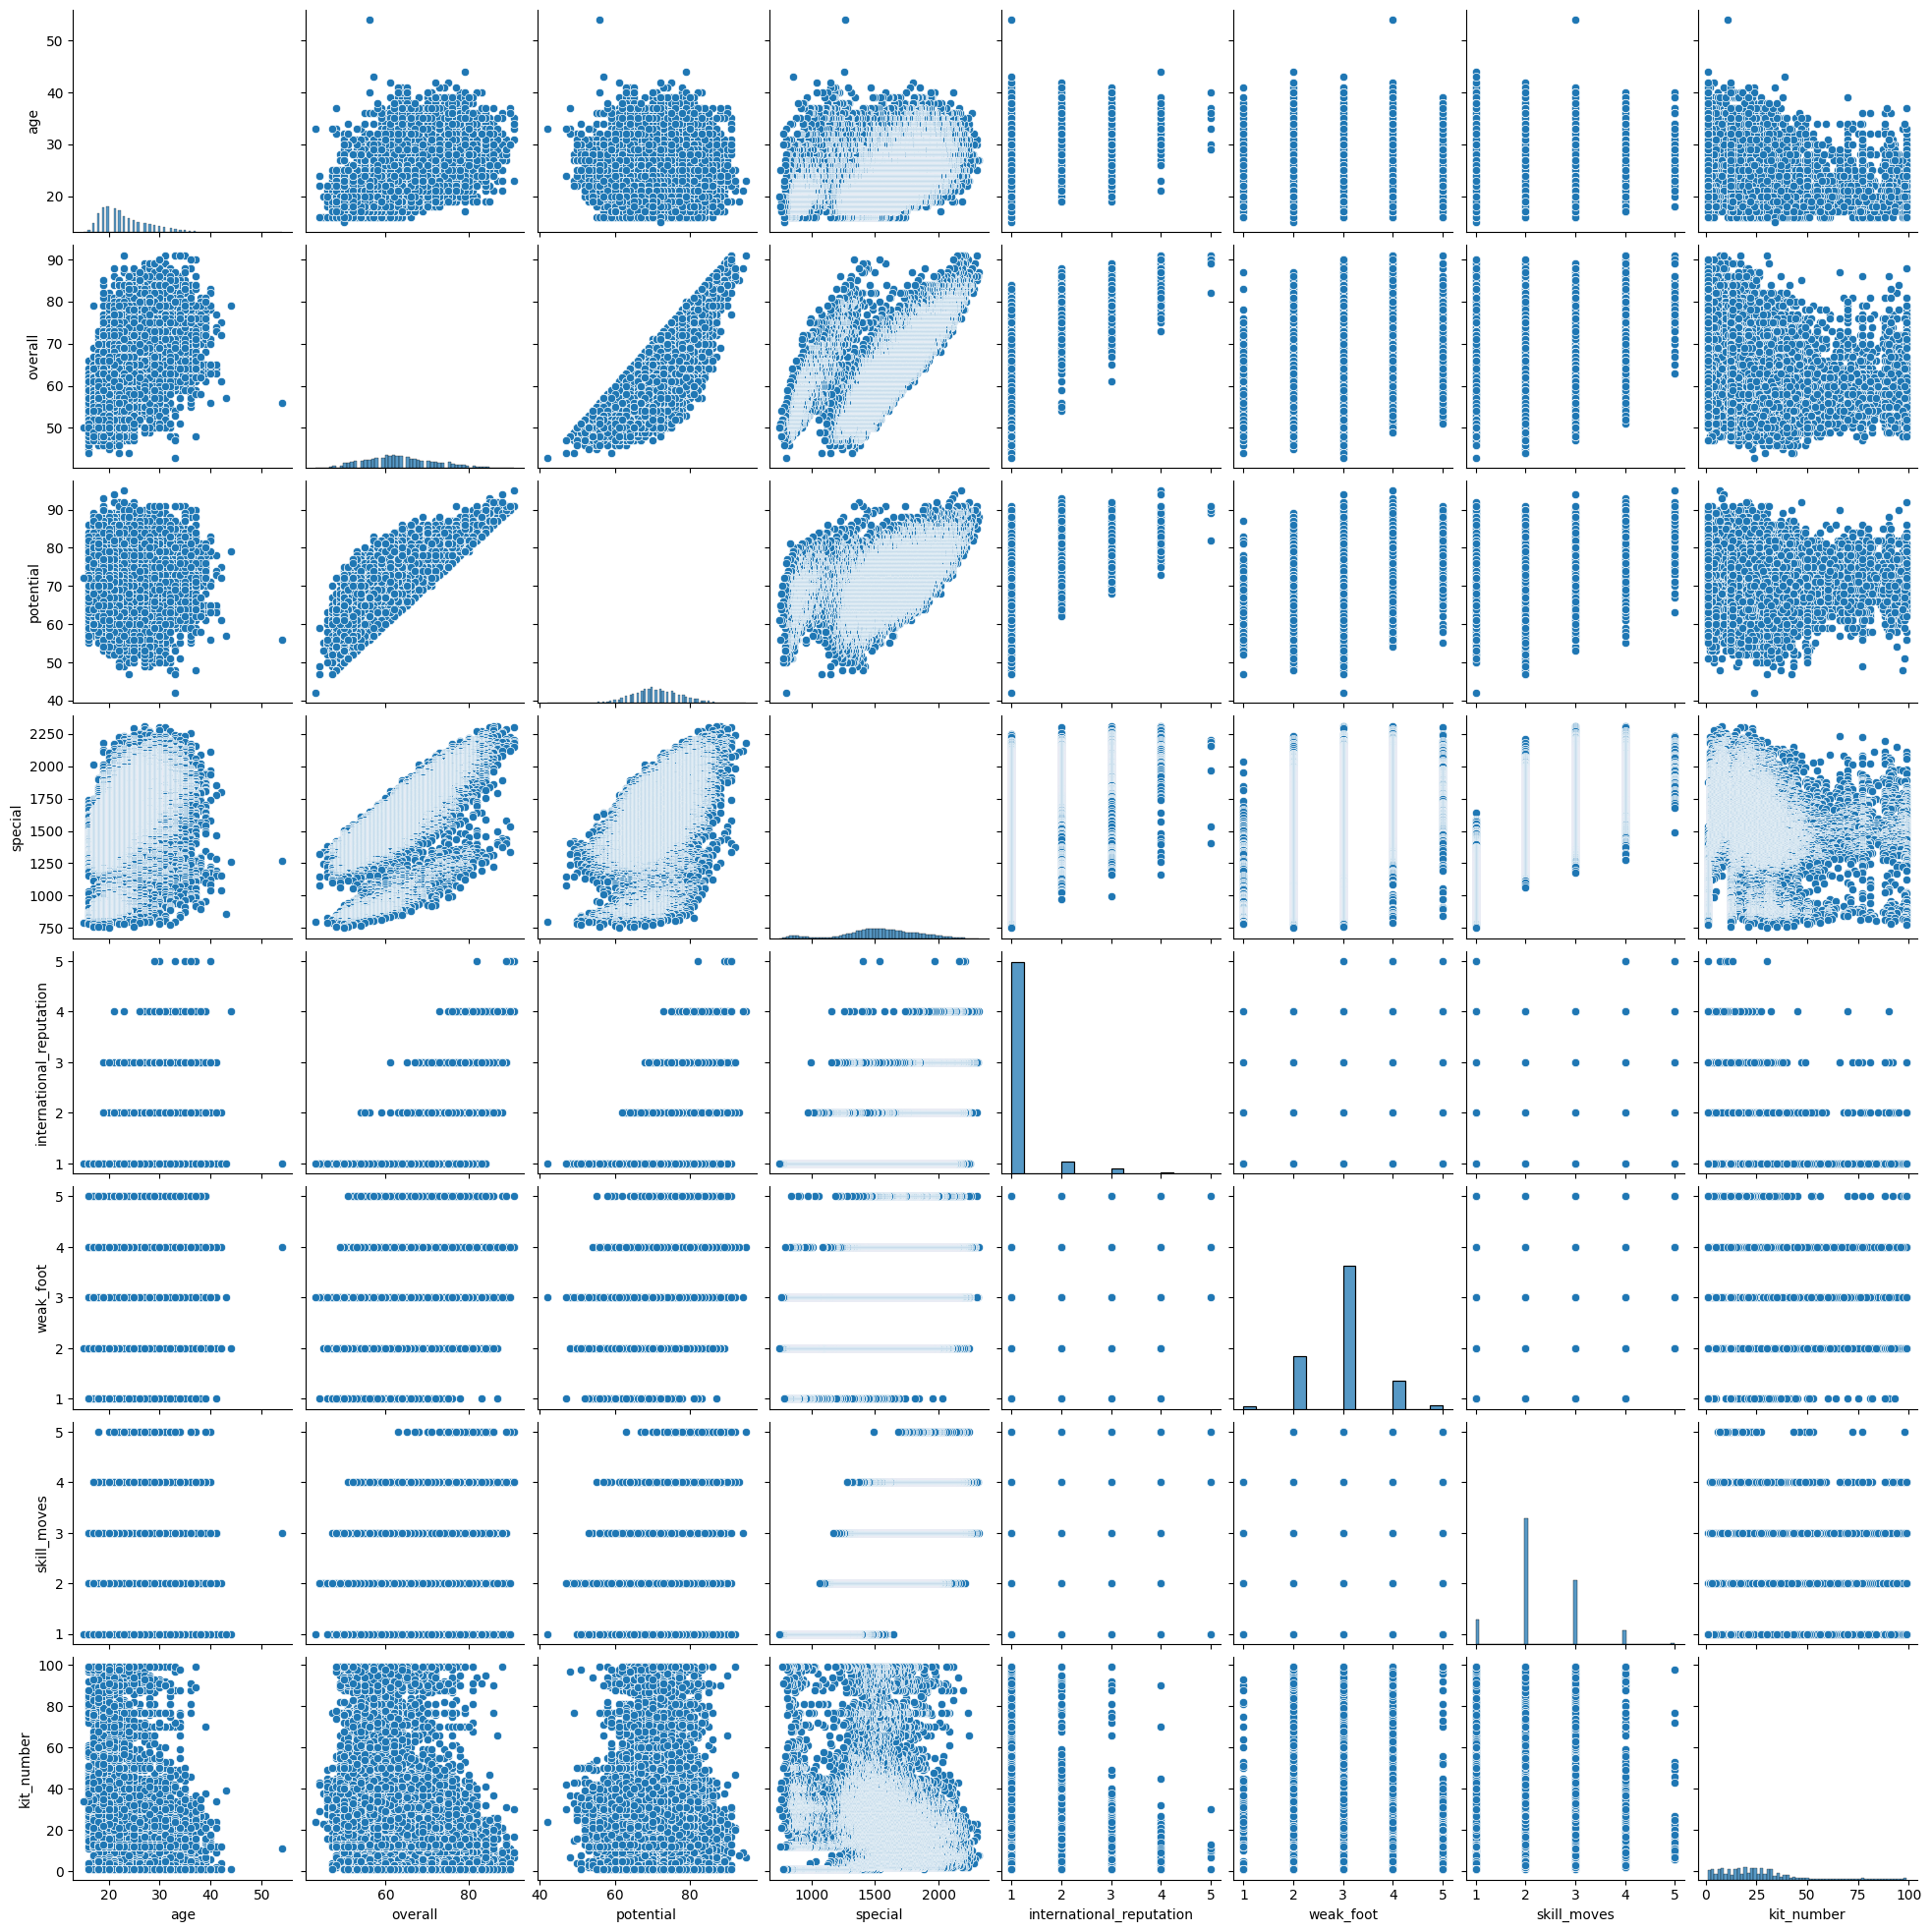

In [166]:
sns.pairplot(df_players[player_numCols])
plt.show()

Al observar la grafica anterior, vamos eliminar de las columnas numericas aquellas que parecen ser discretas debido a la baja cantidad de datos no repetidos lo cual se visualiza en el pairplot anterior. Para el caso vamos a quitar: **`weak_foot`**, **`skill_moves`** y **`kit_number`**.

In [167]:
# player_numCols.remove('international_reputation')
player_numCols.remove('weak_foot')
player_numCols.remove('skill_moves')
player_numCols.remove('kit_number')
player_numCols

['age', 'overall', 'potential', 'special', 'international_reputation']

En lo que respecta a `international_reputation`, la vamos a dejar como variable objetivo pues esta a partir de esta vamos a realizar la clusterización, pero por ahora la vamos a dejar.

In [168]:
player_numCols

['age', 'overall', 'potential', 'special', 'international_reputation']

Vamos a definir un dataframe **`df`** de trabajo tomando inicialmente las columnas anteriores:

In [173]:
features_selected = player_numCols + ['value', 'wage', 'height', 'weight']
#features_selected
df = df_players[features_selected]
df.head(2)

,age,overall,potential,special,international_reputation,value,wage,height,weight
0,27,87,88,2312,4.0,€91M,€115K,189cm,82kg
1,27,86,87,2305,3.0,€78.5M,€190K,179cm,69kg


Como las dos ultimas son categoricas las vamos a volver numericas. A continuación se crean las funciones (creadas con la ayuda de Skynet) para tal fin:

In [174]:
def convert_mk_to_numeric(value):
    if isinstance(value, str):  # Asegurar que el valor es una cadena
        if 'M' in value:
            return float(value.replace('M', '')) * 1e6
        elif 'K' in value:
            return float(value.replace('K', '')) * 1e3
        else:
            return float(value)
    return value  # Si no es string, devolver el valor original

def convert_height_to_numeric(height):
    if isinstance(height, str):  # Asegurar que el valor es una cadena
        return float(height.replace('cm', ''))
    return height  # Si no es string, devolver el valor original

def convert_weight_to_numeric(weight):
    if isinstance(weight, str):  # Asegurar que el valor es una cadena
        return float(weight.replace('kg', ''))
    return weight  # Si no es string, devolver el valor original

Aplicando las funciones anteriores para convertir las columnas a numericas tenemos:

In [175]:
# Columna Value
df['value'] = df['value'].str[1:]
df['value']= df['value'].apply(convert_mk_to_numeric)

# Columna Wage
df['wage'] = df['wage'].str[1:]
df['wage'] = df['wage'].apply(convert_mk_to_numeric)

# Columna Height
df['height'] = df['height'].apply(convert_height_to_numeric)

# Columna Weight
df['weight'] = df['weight'].apply(convert_weight_to_numeric)

# Inspeccion del frame
df.head(2)

<ipython-input-175-500ef998ed91>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['value'] = df['value'].str[1:]
<ipython-input-175-500ef998ed91>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['value']= df['value'].apply(convert_mk_to_numeric)
<ipython-input-175-500ef998ed91>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

,age,overall,potential,special,international_reputation,value,wage,height,weight
0,27,87,88,2312,4.0,91000000.0,115000.0,189.0,82.0
1,27,86,87,2305,3.0,78500000.0,190000.0,179.0,69.0


Ahora, analizamos el dataframe definitivo:

In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17660 entries, 0 to 17659
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       17660 non-null  int64  
 1   overall                   17660 non-null  int64  
 2   potential                 17660 non-null  int64  
 3   special                   17660 non-null  int64  
 4   international_reputation  17660 non-null  float64
 5   value                     17660 non-null  float64
 6   wage                      17660 non-null  float64
 7   height                    17660 non-null  float64
 8   weight                    17660 non-null  float64
dtypes: float64(5), int64(4)
memory usage: 1.2 MB


In [177]:
cantidad_valores_unicos = df.nunique()
print(cantidad_valores_unicos)

age                           31
overall                       49
potential                     50
special                     1428
international_reputation       5
value                        258
wage                         135
height                        51
weight                        58
dtype: int64


Vemos que **To Do...**

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

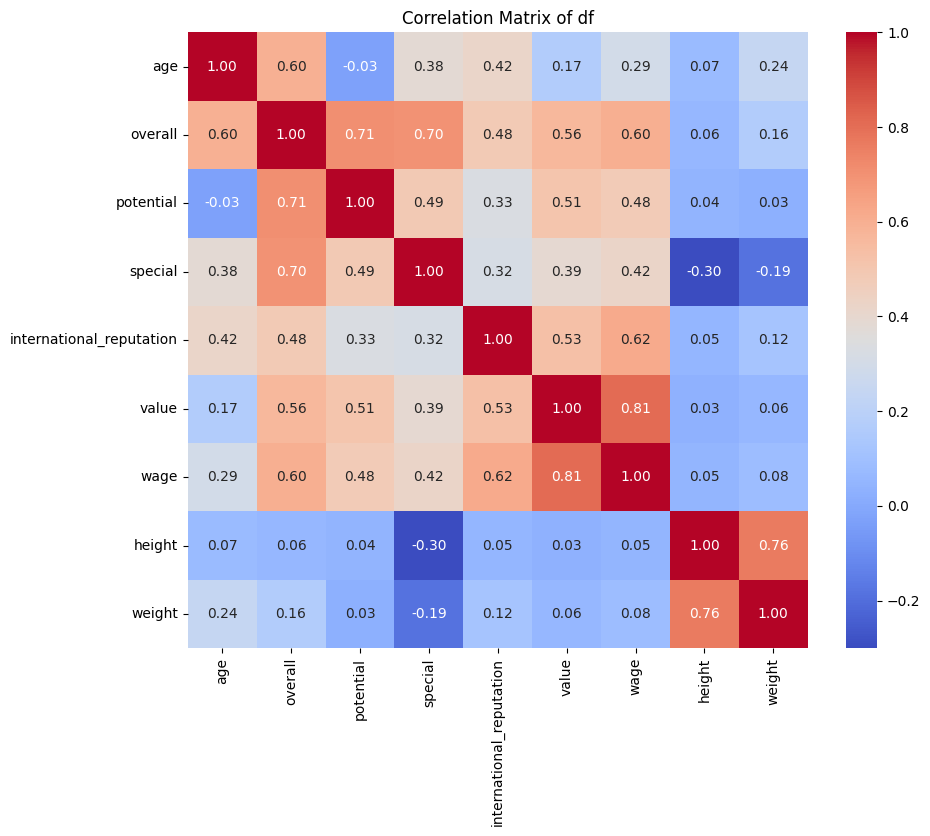

In [178]:
correlation_matrix = df.corr()

# Grafico de la matriz de correlacion
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of df')
plt

Segun la matriz de correlacion anterior, podemos ver lo siguiente:
* Las variables `overall`, `potential` y `special` estan altamente correlacionadas, por lo tanto podemos eliminar una de estas. Como `special` tiene mas valores vamos a dejarla y las otras dos las eliminamos.
* `value` y `wage` tambien lo estan, por lo que vamos a eliminar a `wage` que tiene menos valores diferentes.
* `height` y `weight`, de modo que siguiendo el mismo orden de ideas `height` sale

In [180]:
# Se remueven las variables
features_selected.remove('overall')
features_selected.remove('potential')
features_selected.remove('wage')
features_selected.remove('weight')
# Se muestran las que quedaron
features_selected

['age', 'special', 'international_reputation', 'value', 'height']

In [190]:
df

,age,overall,potential,special,international_reputation,value,wage,height,weight
0,27,87,88,2312,4.0,91000000.0,115000.0,189.0,82.0
1,27,86,87,2305,3.0,78500000.0,190000.0,179.0,69.0
2,30,85,85,2303,2.0,46500000.0,46000.0,172.0,69.0
3,31,91,91,2303,4.0,107500000.0,350000.0,181.0,70.0
4,25,86,89,2296,3.0,89500000.0,110000.0,172.0,68.0
...,...,...,...,...,...,...,...,...,...
17655,19,48,61,762,1.0,100000.0,500.0,190.0,78.0
17656,17,48,64,761,1.0,100000.0,500.0,195.0,84.0
17657,25,51,56,759,1.0,70000.0,2000.0,190.0,82.0
17658,18,50,65,758,1.0,90000.0,500.0,187.0,79.0


Ahora hacemos la grafica del pairplot para las caracteristica seleccionadas, tomando `international_reputation` como variable para segmentar los puntos en el pairplot.

In [193]:
features_selected

['age',
 'special',
 'international_reputation',
 'value',
 'height',
 'international_reputation']

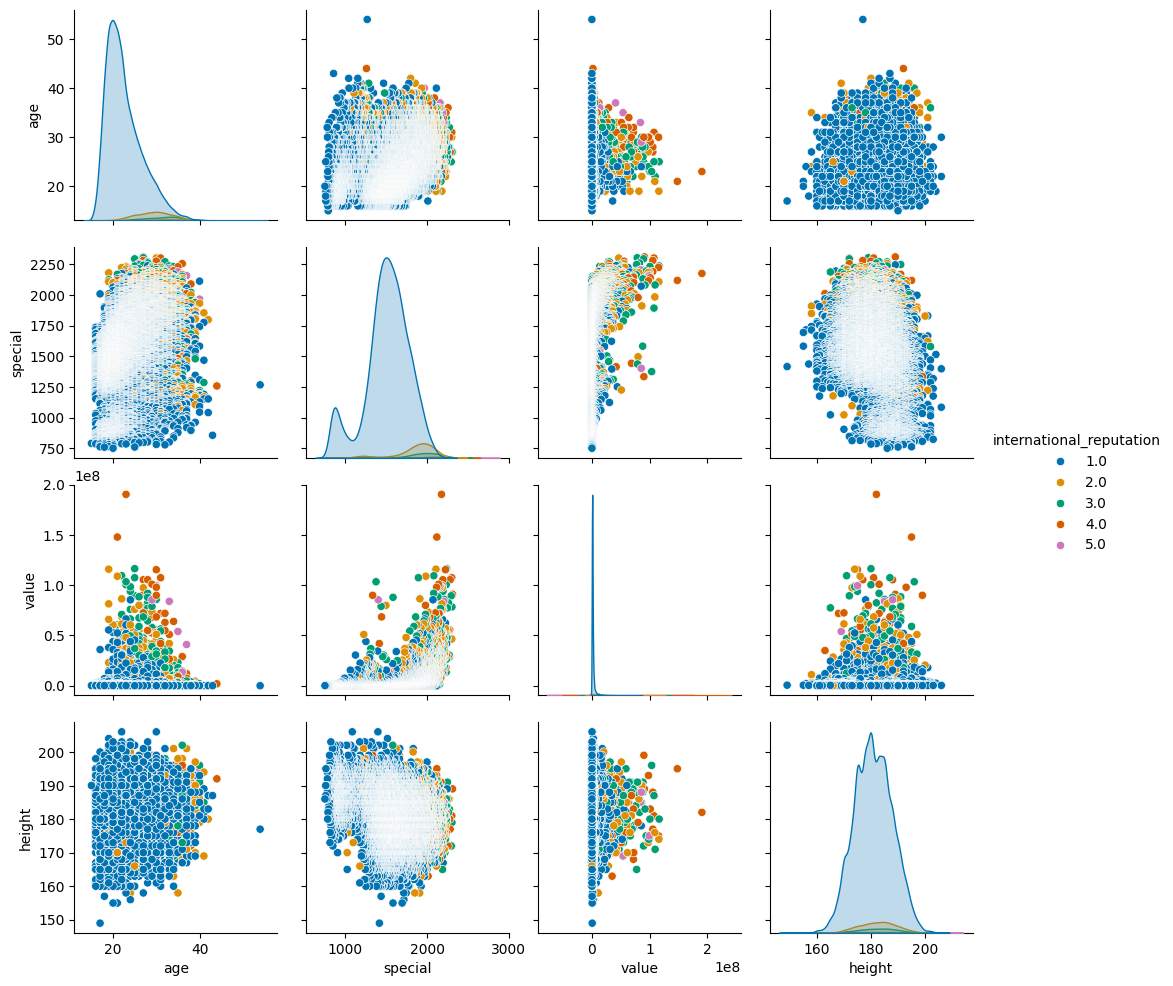

In [196]:
# prompt: pair plot de features_selected de df sin usar la columna international reputation

features_for_pairplot = [col for col in features_selected if col != 'international_reputation']

sns.pairplot(df, vars=features_for_pairplot, hue='international_reputation', palette= 'colorblind')
plt.show()


Es importante notar que la variable objetivo tiene valores que van desde 1 hasta 5, lo cual tiene que ser corregido cuando se vaya a calcular el rand index pues el valor para los cluster va 0 a 4 cuando **K = 5** que es lo que se usará.

#### 3.2. Modelo GMM

A continuación vamos a crear el modelo usando GMM

In [209]:
# Set random seed for reproducibility
np.random.seed(42)

In [203]:
features_selected
variable_objetivo = ['international_reputation']
features_selected.remove(variable_objetivo[0])

In [218]:
df[features_selected].head(3)

,age,special,value,height
0,27,2312,91000000.0,189.0
1,27,2305,78500000.0,179.0
2,30,2303,46500000.0,172.0


In [213]:
df[variable_objetivo].head(3)

,international_reputation
0,4.0
1,3.0
2,2.0


Veamos los valores que toma la variable objetivo:

In [217]:
print(df[variable_objetivo[0]].unique())

[4. 3. 2. 1. 5.]


In [231]:
df['international_reputation_cluster'] = df[variable_objetivo] - 1

<ipython-input-231-999538ed90e4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['international_reputation_cluster'] = df[variable_objetivo] - 1


In [235]:
df[features_selected + ['international_reputation','international_reputation_cluster']].head()

,age,special,value,height,international_reputation,international_reputation_cluster
0,27,2312,91000000.0,189.0,4.0,3.0
1,27,2305,78500000.0,179.0,3.0,2.0
2,30,2303,46500000.0,172.0,2.0,1.0
3,31,2303,107500000.0,181.0,4.0,3.0
4,25,2296,89500000.0,172.0,3.0,2.0


En el caso anterior, vamos a usar el valor de la columna `international_reputation_cluster` para comparar con el cluster resultante en la metrica rand index

Como vamos a tratar de segmentar de acuerdo a la variable objetivo la cual toma 5 valores tenemos **`K = 5`**:


In [246]:
K = 5
X = df[features_selected].values
y = df['international_reputation_cluster'].values # Valores objetivo
n, d = X.shape  # Number of samples
print(f"filas: {n}")
print(f"Columnas: {d}")
print(f"Numero de clusters: {K}")

filas: 17660
Columnas: 4
Numero de clusters: 5


Inicialización de parametros

In [247]:
# Initialize parameters
epsilon = 1e-6  # Small value to prevent log(0)

# Normalize data
# X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)  # Standardize features

# Mixing coefficients (initial uniform distribution)
pi = np.ones(K) / K

# Initialize means using random samples from data
random_indices = np.random.choice(n, K, replace=False)
mu = X_norm[random_indices, :]

# Initialize covariance matrices
Sigma = np.array([generate_positive_definite_matrix(d) for _ in range(K)])

Aplicación del algoritmo EM

Iteración 1, Log-Verosimilitud: -634355.3208
Iteración 2, Log-Verosimilitud: -649734.4958
Iteración 3, Log-Verosimilitud: -678922.5893
Iteración 4, Log-Verosimilitud: -717244.5656
Iteración 5, Log-Verosimilitud: -761589.9024
Iteración 6, Log-Verosimilitud: -803055.3451
Iteración 7, Log-Verosimilitud: -834222.8894
Iteración 8, Log-Verosimilitud: -855528.9507
Iteración 9, Log-Verosimilitud: -870883.3675
Iteración 10, Log-Verosimilitud: -882846.8484
Iteración 11, Log-Verosimilitud: -892600.8990
Iteración 12, Log-Verosimilitud: -900761.5171
Iteración 13, Log-Verosimilitud: -907571.8446
Iteración 14, Log-Verosimilitud: -913192.7058
Iteración 15, Log-Verosimilitud: -917746.1251
Iteración 16, Log-Verosimilitud: -921348.7774
Iteración 17, Log-Verosimilitud: -924225.2219
Iteración 18, Log-Verosimilitud: -926610.9725
Iteración 19, Log-Verosimilitud: -928674.1714
Iteración 20, Log-Verosimilitud: -930515.8742
Iteración 21, Log-Verosimilitud: -932193.6466
Iteración 22, Log-Verosimilitud: -933740.93

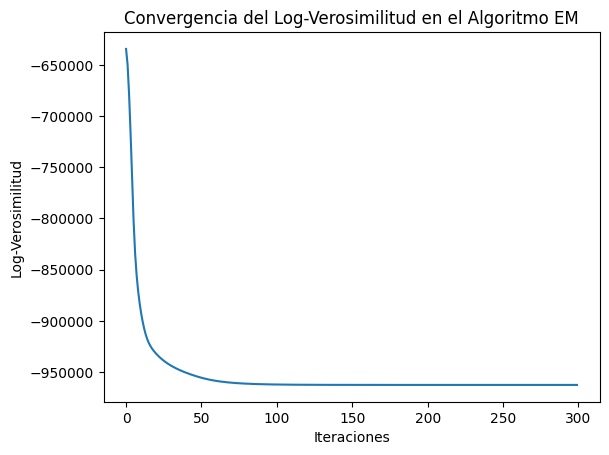

In [248]:
pi_final, mu_final, Sigma_final, gamma_final, log_likelihoods = expectation_maximization(X_norm, mu, Sigma, pi, max_iters= 300)

In [249]:
# Assign cluster labels based on maximum responsibility
Z = np.argmax(gamma_final, axis=1)
df['cluster'] = Z
df.head()

<ipython-input-249-b9c7f9b29b04>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = Z


,age,overall,potential,special,international_reputation,value,wage,height,weight,cluster,international_reputation_cluster
0,27,87,88,2312,4.0,91000000.0,115000.0,189.0,82.0,1,3.0
1,27,86,87,2305,3.0,78500000.0,190000.0,179.0,69.0,1,2.0
2,30,85,85,2303,2.0,46500000.0,46000.0,172.0,69.0,1,1.0
3,31,91,91,2303,4.0,107500000.0,350000.0,181.0,70.0,1,3.0
4,25,86,89,2296,3.0,89500000.0,110000.0,172.0,68.0,1,2.0


Obtenemos el rand index entre las columnas asociadas al valor esperado para la reputación internacional (corregido de 0 a 4) `international_reputation_cluster` con el valor predicho para el `cluster`.

In [252]:
# Assuming 'y' and 'df['cluster']' are your true and predicted cluster labels respectively
rand_index = rand_score(df['international_reputation_cluster'], df['cluster'])
print(f"Rand Index: {rand_index}")

Rand Index: 0.856040997384899


Segun lo anterior podemos concluir que **To Do...**

Ahora miremos la cantidad de valores para `cluster` y comparemos esto con la cantidad de valores para `international_reputation_cluster`

In [254]:
# Conteo
df_comparacion = pd.DataFrame({'international_reputation_cluster': df['international_reputation_cluster'].value_counts(),
                               'cluster': df['cluster'].value_counts()})
df_comparacion

,international_reputation_cluster,cluster
0.0,16312,15615
1.0,907,157
2.0,360,357
3.0,74,1516
4.0,7,15


De la tabla anterior podemos ver que **To Do**

In [256]:
df[features_selected].head()

,age,special,value,height
0,27,2312,91000000.0,189.0
1,27,2305,78500000.0,179.0
2,30,2303,46500000.0,172.0
3,31,2303,107500000.0,181.0
4,25,2296,89500000.0,172.0


Ahora observemos el pairplot obtenido para las caracteristicas elegidas empleando el cluster como elemento de segmentación.

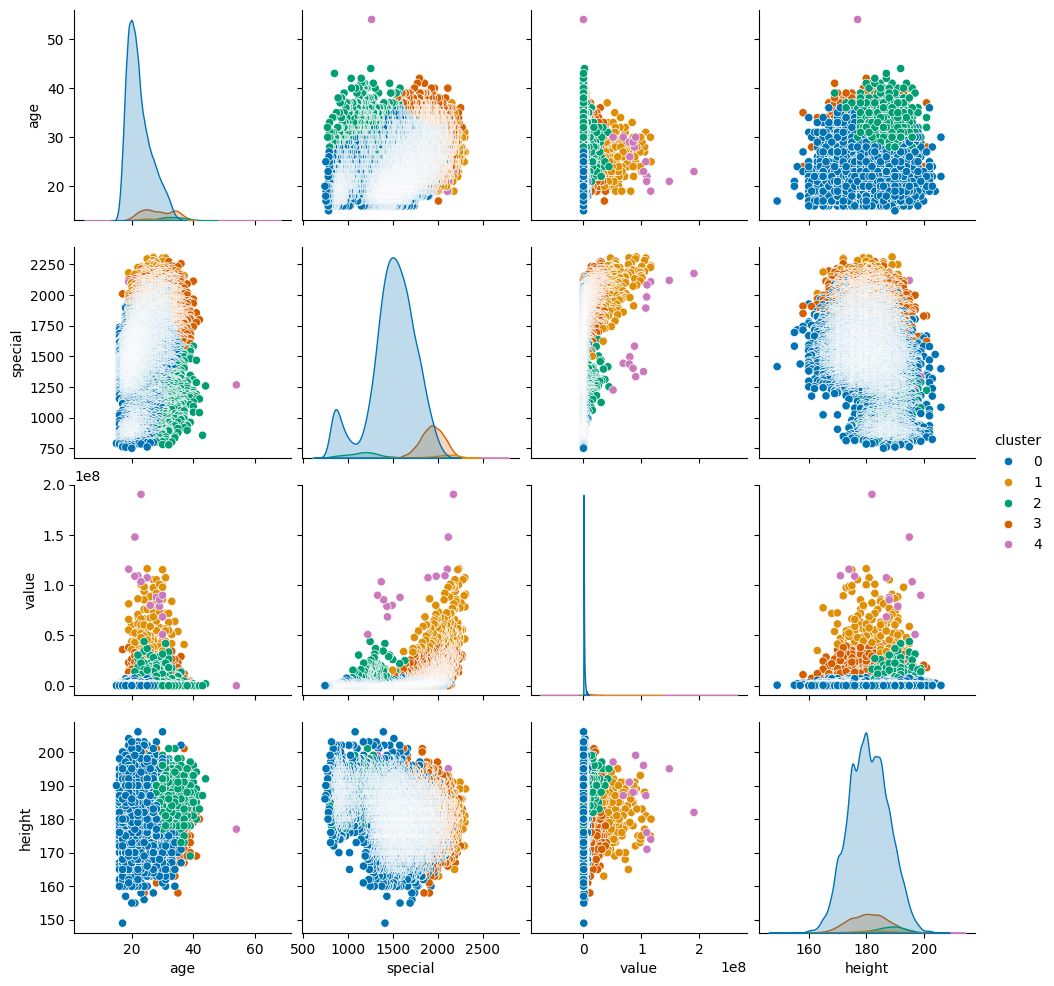

In [268]:
features = ['age', 'special', 'value', 'height', 'cluster']
sns.pairplot(df[features], hue='cluster', palette='colorblind')
plt.show()

In [270]:
# Agrupar por cluster y calcular estadísticas descriptivas
cluster_summary = df[features].groupby('cluster').agg(['min', 'mean', 'max', 'std']).round(2)

# Mostrar la tabla
cluster_summary.T

cluster                0             1            2            3             4
age     min        15.00  1.900000e+01        21.00        17.00  1.900000e+01
        mean       22.34  2.597000e+01        32.80        28.63  2.733000e+01
        max        36.00  3.700000e+01        44.00        42.00  5.400000e+01
        std         3.93  3.500000e+00         4.20         5.09  8.290000e+00
special min       749.00  1.501000e+03       777.00      1522.00  1.225000e+03
        mean     1501.93  2.069290e+03      1167.41      1939.52  1.662000e+03
        max      2148.00  2.312000e+03      1755.00      2273.00  2.177000e+03
        std       258.56  1.486500e+02       180.55       126.96  3.532600e+02
value   min         0.00  1.550000e+07         0.00         0.00  0.000000e+00
        mean  1081614.47  5.873567e+07   4653487.39  12655974.93  9.506667e+07
        max   9000000.00  1.165000e+08  44000000.00  41500000.00  1.905000e+08
        std   1261012.55  1.935337e+07   8316638.42   9582864.08  4.252179e+07
height  min       149.00  1.630000e+02       169.00       158.00  1.710000e+02
        mean      180.73  1.822400e+02       188.26       180.68  1.866000e+02
        max       206.00  1.960000e+02       201.00       201.00  1.990000e+02
        std         6.93  6.570000e+00         5.09         6.69  8.830000e+00

Segun lo anterior **To Do...**

Ahora hagamos los histogramas para las variables que se usaron como predictores segun el cluster.

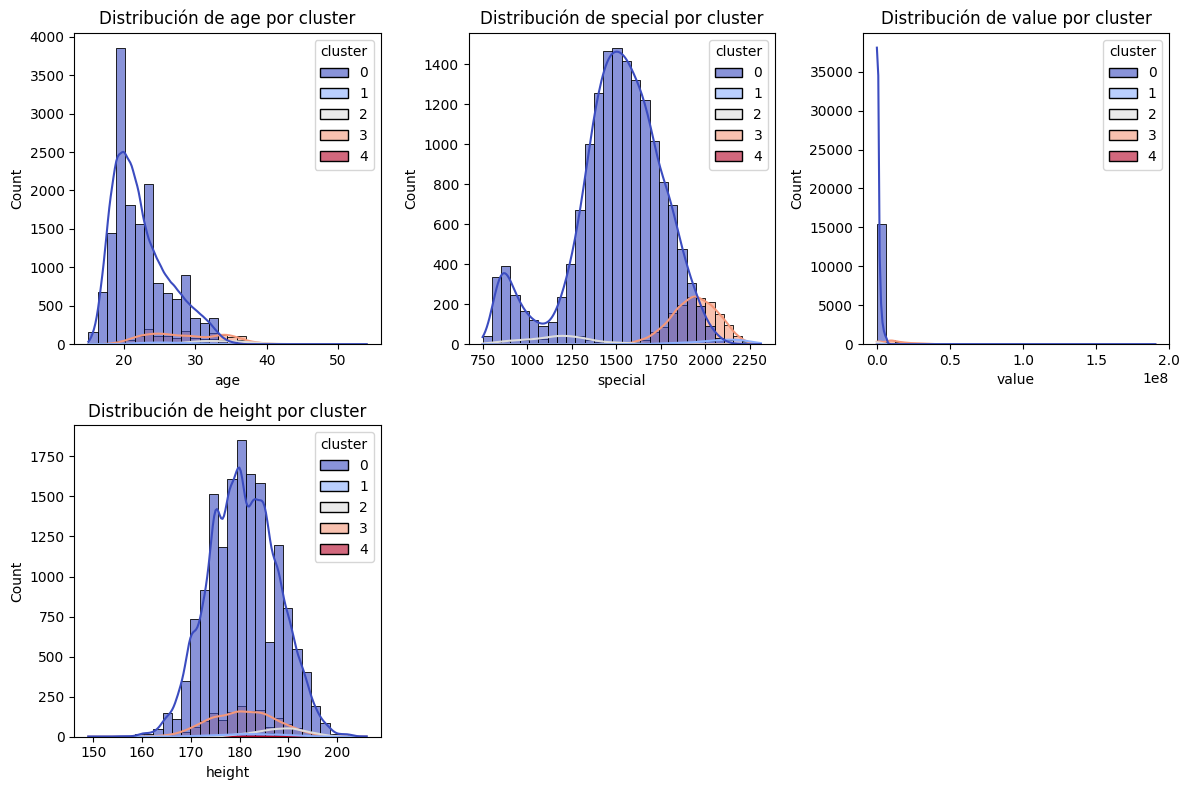

In [272]:
# Gracias skynet
plt.figure(figsize=(12, 8))

variables_predictoras = ['age', 'special', 'value', 'height']

# Histogramas para las variables predictoras respecto a la salida award?
for i, column in enumerate(variables_predictoras, 1):
    plt.subplot(2, 3, i)  # Organiza en una cuadrícula de 2 filas, 3 columnas
    sns.histplot(data = df, x=column, hue="cluster", kde=True, bins=30, palette="coolwarm", alpha=0.6)
    plt.title(f"Distribución de {column} por cluster")

plt.tight_layout()
plt.show()

De lo anterior podemos ver que **To Do...**

Finalmente graficamos el diagrama de cajas y vigotes para las predictoras discriminadas por cluster.

<ipython-input-273-5af990bf8778>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y = column, data = df, palette="coolwarm")
<ipython-input-273-5af990bf8778>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y = column, data = df, palette="coolwarm")
<ipython-input-273-5af990bf8778>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y = column, data = df, palette="coolwarm")
<ipython-input-273-5af990bf8778>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed 

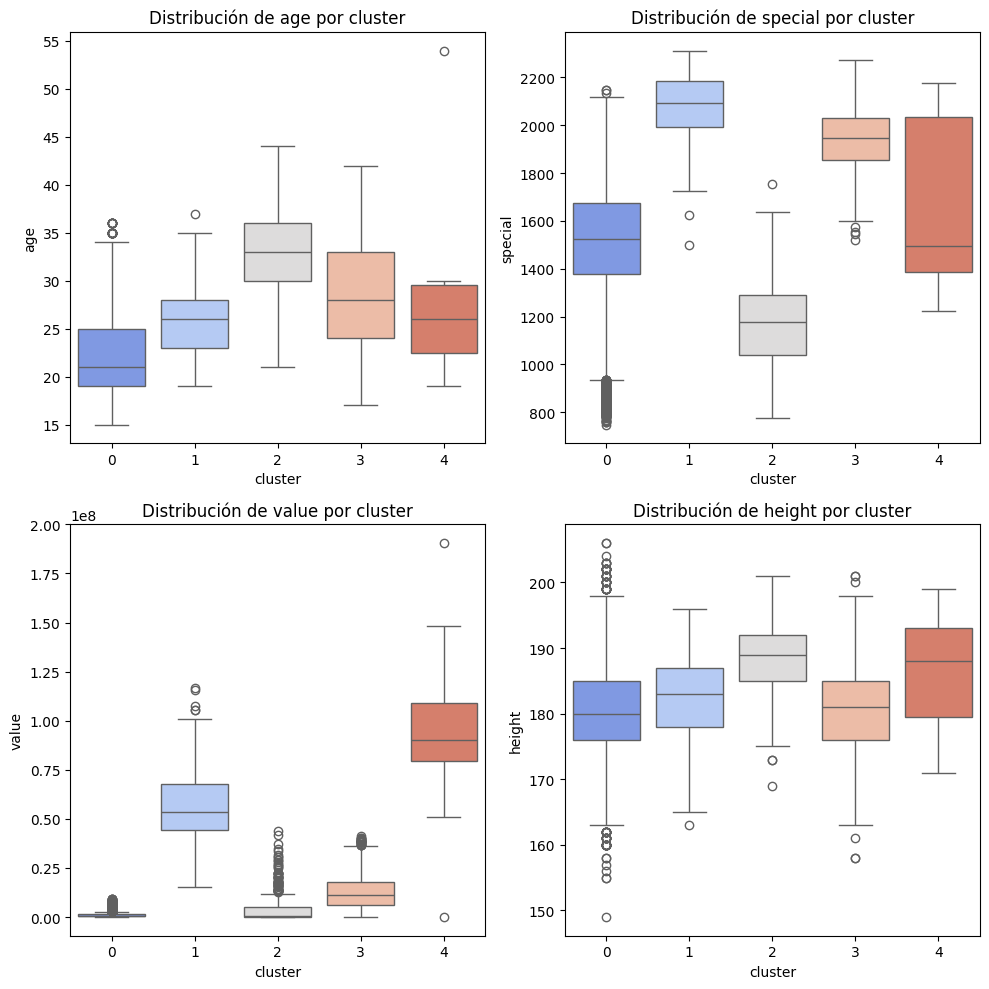

In [273]:
# Crear la figura con subgráficos (2 boxplots por columna)
plt.figure(figsize=(10, 10))

# Calcular el número de filas necesarias (2 gráficos por columna)
num_filas = (len(variables_predictoras) + 1) // 2

# Generar los boxplots
for i, column in enumerate(variables_predictoras, 1):
    plt.subplot(num_filas, 2, i)  # Configurar 2 gráficos por columna
    sns.boxplot(x="cluster", y = column, data = df, palette="coolwarm")
    plt.title(f"Distribución de {column} por cluster")

plt.tight_layout()
plt.show()

Los resultados anteriores muestran que **To do...**

#### 3.3. Resultados y conclusiones

**To do...**

### 4. Dataset aerolineas

La siguiente tabla resume la información del dataset:

| Campo               | Descripción |
|---------------------|-------------|
| `ID#`                | ID único |
| `Balance`           | Número de millas elegibles para viajes con premio |
| `Qual_miles`        | Número de millas que califican para el estatus Topflight |
| `cc1_miles`        | Número de millas ganadas con la tarjeta de crédito de viajero frecuente en los últimos 12 meses |
| `cc2_miles`        | Número de millas ganadas con la tarjeta de crédito Rewards en los últimos 12 meses |
| `cc3_miles`        | Número de millas ganadas con la tarjeta de crédito para pequeñas empresas en los últimos 12 meses |
| `Bonus_miles`      | Número de millas ganadas por transacciones de bonificación no relacionadas con vuelos en los últimos 12 meses |
| `Bonus_trans`      | Número de transacciones de bonificación no relacionadas con vuelos en los últimos 12 meses |
| `Flight_miles_12mo` | Número de millas de vuelo en los últimos 12 meses |
| `Flight_trans_12`  | Número de transacciones de vuelo en los últimos 12 meses |
| `Days_since_enroll` | Número de días desde la fecha de inscripción |
| `Award?`           | Variable indicadora para el último premio (1= no nulo, 0= nulo) |

#### 4.1. Carga de datos

In [4]:
# Se carga el dataset
xlsx_file = 'EastWestAirlines.xlsx'
df_airlines = pd.read_excel(xlsx_file, sheet_name='data')
df_airlines.head(3)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0


In [5]:
df_airlines.shape

(3999, 12)

In [6]:
df_airlines.columns = df_airlines.columns.str.lower()
df_airlines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id#                3999 non-null   int64
 1   balance            3999 non-null   int64
 2   qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   bonus_miles        3999 non-null   int64
 7   bonus_trans        3999 non-null   int64
 8   flight_miles_12mo  3999 non-null   int64
 9   flight_trans_12    3999 non-null   int64
 10  days_since_enroll  3999 non-null   int64
 11  award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


Ahora se procede a verificar la cantidad de valores nulos.

In [7]:
# checking the missing values
df_airlines.isnull().sum()

,0
id#,0
balance,0
qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
bonus_miles,0
bonus_trans,0
flight_miles_12mo,0
flight_trans_12,0


Como se puede observar en los resultados anteriores podemos llegar a las siguientes conclusiones:
* Todas las caracteristicas son numericas.
* El dataset esta completo ya que no tiene valores nulos.
* La columna asociada al `id` se puede descartar pues indica un identificador unico.
* Es importante resaltar mediante el conteo de valores para cada columna la cantidad de datos diferentes, esto con el fin de determinar cuales de estas variables numericas se asocian a una categoria. Esto se hace a continuación.

Ahora mostramos la cantidad diferentes por feature.

In [8]:
unique_values_count = df_airlines.nunique()
print(unique_values_count)

id#                  3999
balance              3904
qual_miles            164
cc1_miles               5
cc2_miles               3
cc3_miles               5
bonus_miles          2734
bonus_trans            57
flight_miles_12mo     343
flight_trans_12        35
days_since_enroll    2820
award?                  2
dtype: int64


A continuación se muestra un resumen estadistico de las features asociadas al dataset.

In [16]:
df_airlines.describe().T

,count,mean,std,min,25%,50%,75%,max
id#,3999.0,2014.819455,1160.764358,1.0,1010.5,2016.0,3020.5,4021.0
balance,3999.0,73601.327582,100775.664958,0.0,18527.5,43097.0,92404.0,1704838.0
qual_miles,3999.0,144.114529,773.663804,0.0,0.0,0.0,0.0,11148.0
cc1_miles,3999.0,2.059515,1.376919,1.0,1.0,1.0,3.0,5.0
cc2_miles,3999.0,1.014504,0.147650,1.0,1.0,1.0,1.0,3.0
cc3_miles,3999.0,1.012253,0.195241,1.0,1.0,1.0,1.0,5.0
bonus_miles,3999.0,17144.846212,24150.967826,0.0,1250.0,7171.0,23800.5,263685.0
bonus_trans,3999.0,11.601900,9.603810,0.0,3.0,12.0,17.0,86.0
flight_miles_12mo,3999.0,460.055764,1400.209171,0.0,0.0,0.0,311.0,30817.0
flight_trans_12,3999.0,1.373593,3.793172,0.0,0.0,0.0,1.0,53.0


De aqui podemos ver que **To Do...**

Para mayor claridad usamos una grafica de barras para ver la informacion anterior.

<ipython-input-17-653f8a5410ba>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_values_count.values, y=unique_values_count.index, palette="viridis")


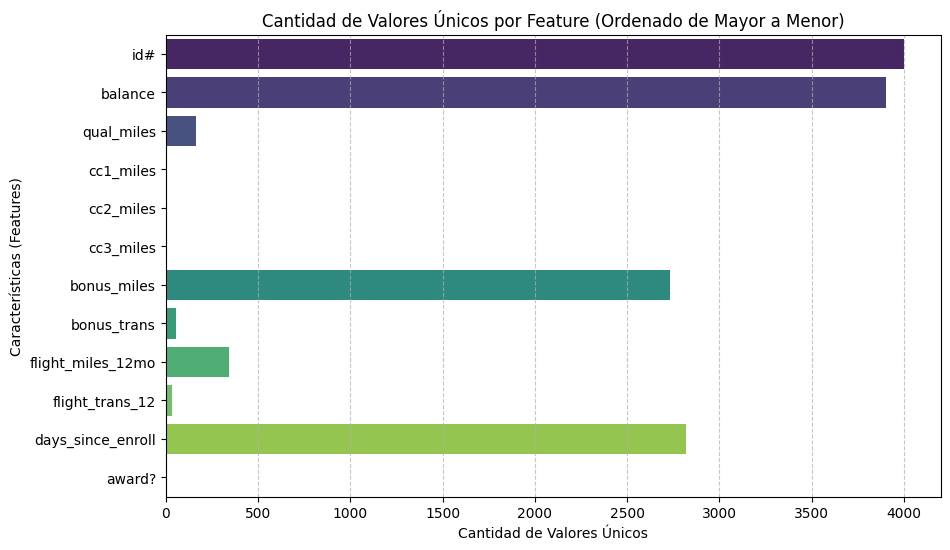

In [17]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crear la gráfica de barras horizontales con Seaborn
sns.barplot(x=unique_values_count.values, y=unique_values_count.index, palette="viridis")

# Agregar etiquetas y título
plt.xlabel("Cantidad de Valores Únicos")
plt.ylabel("Características (Features)")
plt.title("Cantidad de Valores Únicos por Feature (Ordenado de Mayor a Menor)")
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Mostrar la gráfica
plt.show()

Como se puede ver en el resultado anterior, hay unas variables que tienen pocos valores diferentes: `cc1_miles`, `cc2_miles`, `cc3_miles` y `award?`. En lo que respecta al caso de la caracteristica `award?`, esta será empleada como variable objetivo. A continuación se remueven estas variables:

In [18]:
"""
Se remueven algunas variables.

Nota: Hay muchos comentario que se dejaron debido a teras de ensayo y error antes de llegar a una solucion.
"""
# df2 = df_airlines.drop(columns=['id#','cc1_miles', 'cc2_miles', 'cc3_miles', 'award?'])
# df2 = df_airlines.drop(columns=['qual_miles','id#','cc1_miles', 'cc2_miles', 'cc3_miles', 'award?'])
# df2 = df_airlines.drop(columns=['balance','qual_miles','id#','cc1_miles', 'cc2_miles', 'cc3_miles', 'award?'])
# df2 = df_airlines.drop(columns=['balance','id#','cc1_miles', 'cc2_miles', 'cc3_miles', 'award?'])
# df2 = df_airlines.drop(columns=['qual_miles','id#', 'bonus_trans', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'award?'])
df2 = df_airlines.drop(columns=['qual_miles','id#','cc1_miles', 'cc2_miles', 'cc3_miles'])

# Despliegue del dataframe para verificar los resultados
df2.head(3)

,balance,bonus_miles,bonus_trans,flight_miles_12mo,flight_trans_12,days_since_enroll,award?
0,28143,174,1,0,0,7000,0
1,19244,215,2,0,0,6968,0
2,41354,4123,4,0,0,7034,0


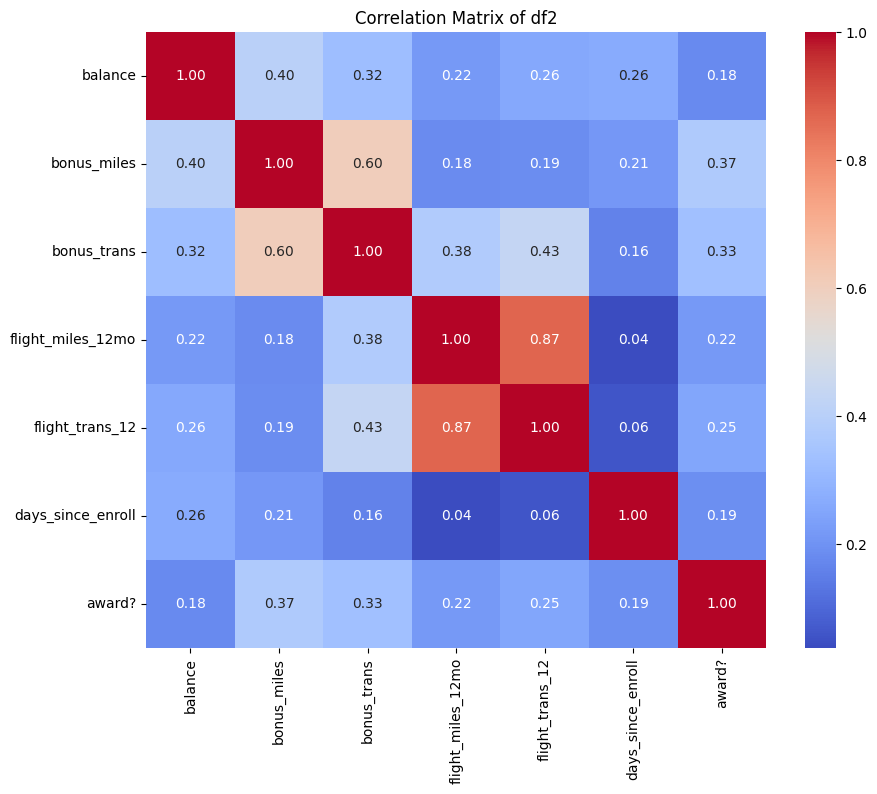

In [19]:
# Calculo de la matriz de correlacion
correlation_matrix = df2.corr()

# Grafico de la matriz de correlacion
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of df2')
plt.show()


De la figura anterior vemos que con respecto a la variable objetivo, las variables predictoras tienen muy poca correlación, sin embargo entre las variables `flight_miles_12mo`	y `flight_trans_12`. Como la correlación es mayor con respecto a `award?` de `flight_trans_12`, vamos a dejar esta.

In [30]:
# Se elimina la columna "Flight_miles_12mo" del DataFrame
try:
    df2.drop(['flight_miles_12mo'], axis=1, inplace=True)
except KeyError:
    pass

# Se verifica que la columna fue eliminada
variables_predictoras = ["balance", "bonus_miles", "bonus_trans", "flight_trans_12", "days_since_enroll"]
df2.head(3)

,balance,bonus_miles,bonus_trans,flight_trans_12,days_since_enroll,award?
0,28143,174,1,0,7000,0
1,19244,215,2,0,6968,0
2,41354,4123,4,0,7034,0


Vamos a ver el diagrama de cajas y bigotes para cada uno de los predictores.

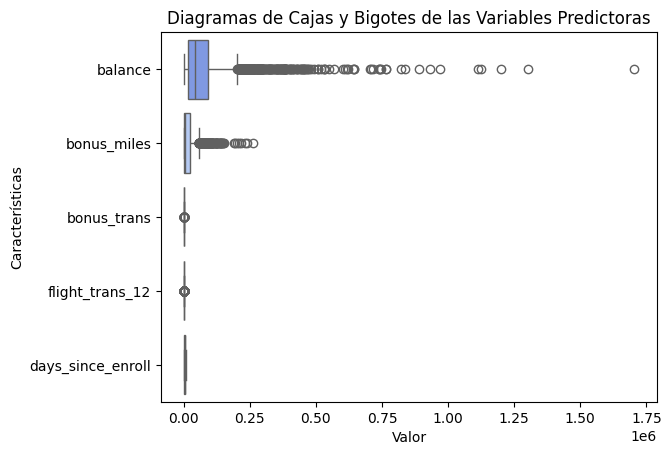

In [31]:
# Agradecimientos: Skynet
sns.boxplot(data=df2[variables_predictoras], orient="h", palette="coolwarm")

# Agregar título
plt.title("Diagramas de Cajas y Bigotes de las Variables Predictoras")
plt.xlabel("Valor")
plt.ylabel("Características")

# Mostrar el gráfico
plt.show()

Del diagram anterior se puede notar que **To Do...**

Para tener una visión mas cercana de la distribución de las variables predictoras; a continuación, se muestran los histogramas de cada una de estas:

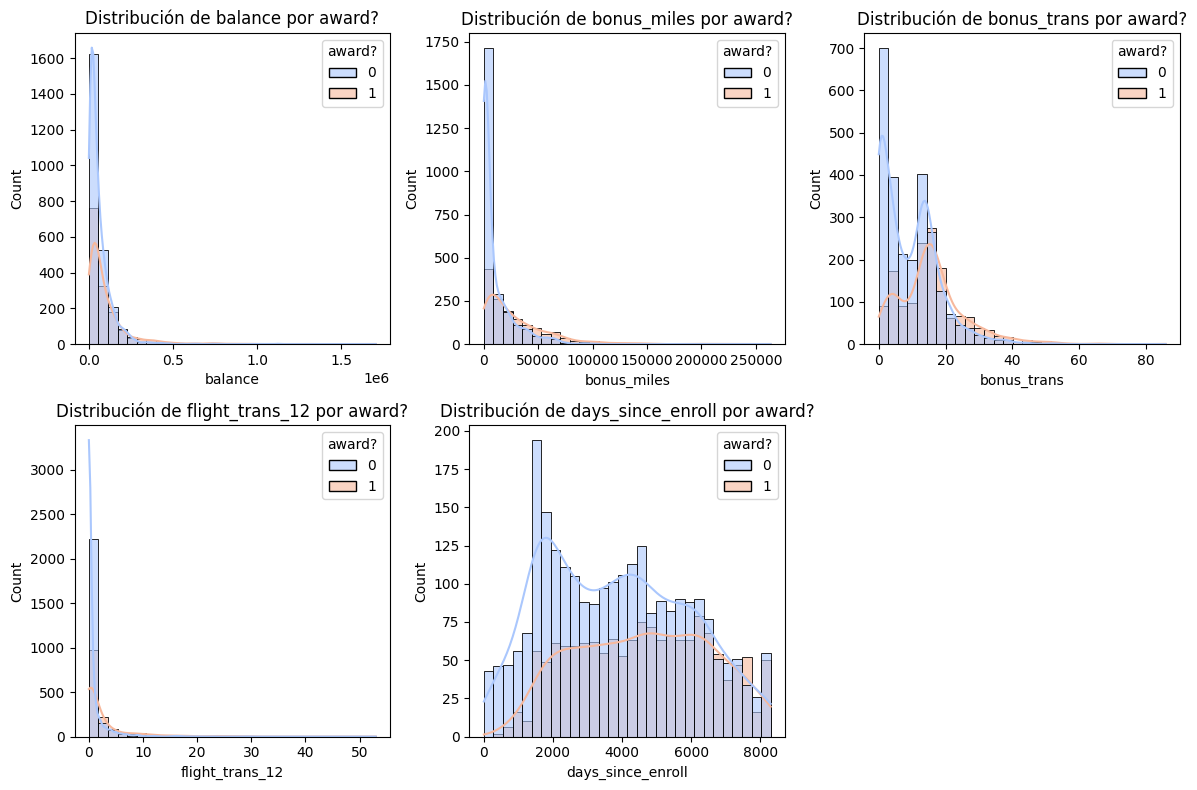

In [36]:
# Gracias skynet
plt.figure(figsize=(12, 8))

# Histogramas para las variables predictoras respecto a la salida award?
for i, column in enumerate(variables_predictoras, 1):
    plt.subplot(2, 3, i)  # Organiza en una cuadrícula de 2 filas, 3 columnas
    sns.histplot(data = df2, x=column, hue="award?", kde=True, bins=30, palette="coolwarm", alpha=0.6)
    plt.title(f"Distribución de {column} por award?")

plt.tight_layout()
plt.show()

De la grafica anterior ver que **To Do...**

Ahora miremos la relación entre las variables predictoras y la variable objetivo `award?` mediante un pairplot.

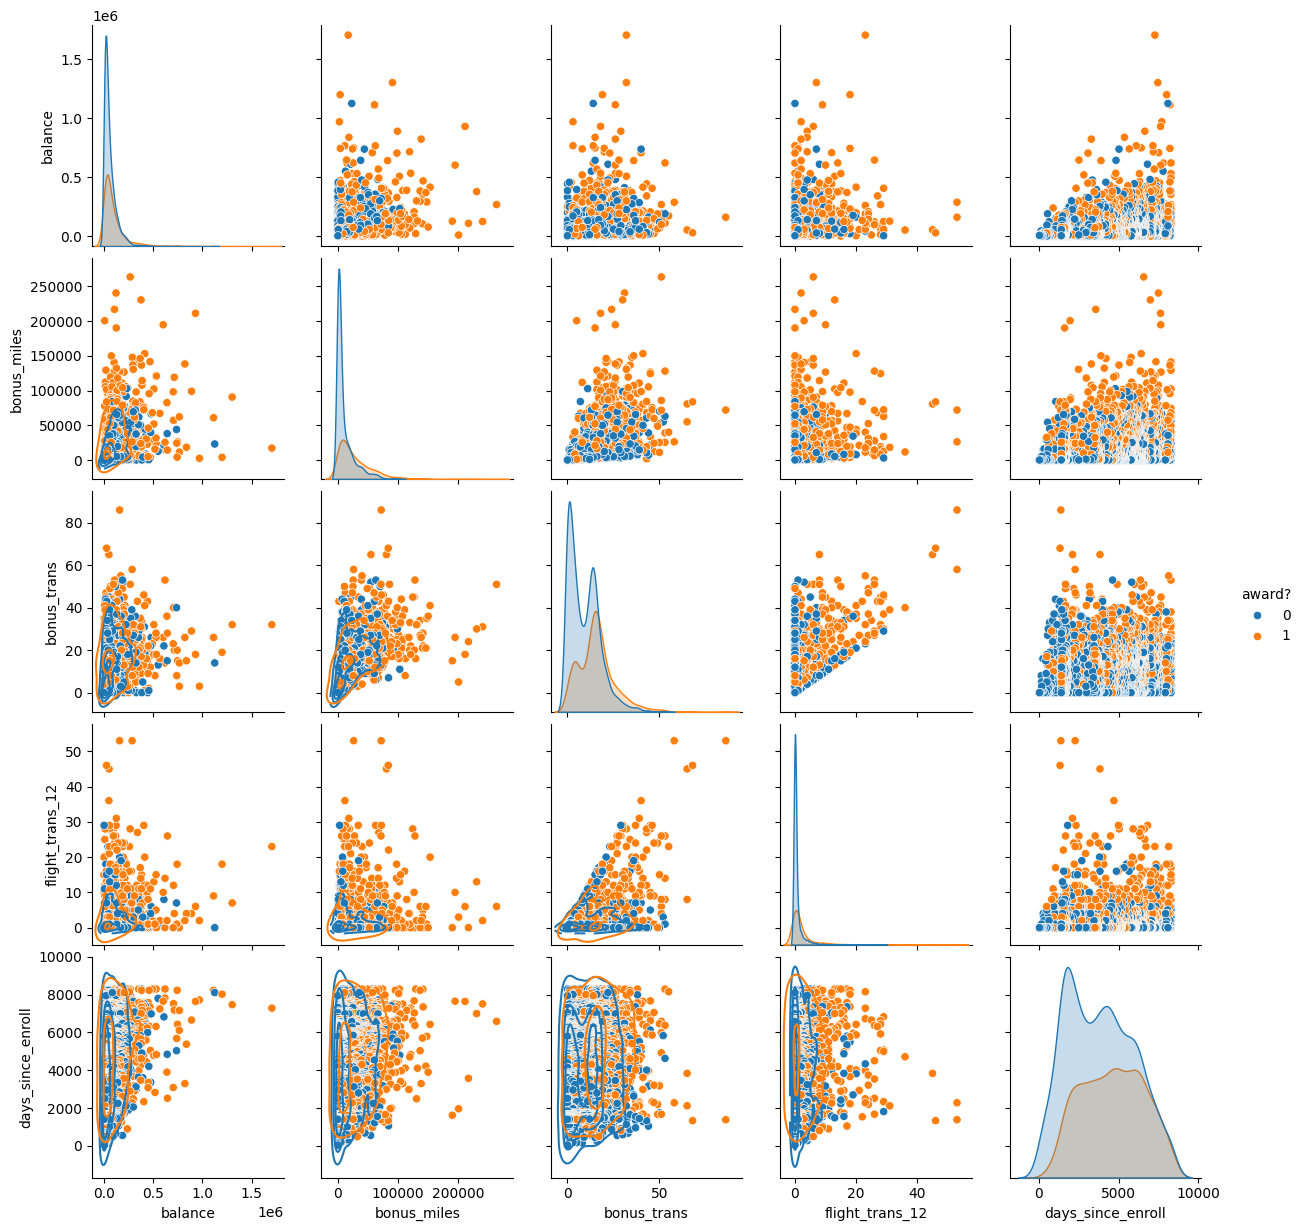

In [33]:
# Lista de variables predictoras + variable objetivo
g = sns.pairplot(df2, diag_kind="kde", hue="award?")
g.map_lower(sns.kdeplot, levels=4, color=".2")

#### 4.2. GMM

A continuación vamos a crear el modelo usando GMM

In [37]:
try:
    df2.drop(['cluster'], axis=1, inplace=True)
except KeyError:
    pass
df2.head(3)

,balance,bonus_miles,bonus_trans,flight_trans_12,days_since_enroll,award?
0,28143,174,1,0,7000,0
1,19244,215,2,0,6968,0
2,41354,4123,4,0,7034,0


In [38]:
# Set random seed for reproducibility
np.random.seed(42)
# np.random.seed(np.random.randint(0, 1000))

Como vamos a tratar de segmentar de acuerdo a la variable de salida asociada al premio (`aware?`) vamos a emplear **`K = 2`** como el numero de clusters

In [45]:
# Datos de entrada para entrenar el modelo
df2[variables_predictoras].head()

,balance,bonus_miles,bonus_trans,flight_trans_12,days_since_enroll
0,28143,174,1,0,7000
1,19244,215,2,0,6968
2,41354,4123,4,0,7034
3,14776,500,1,0,6952
4,97752,43300,26,4,6935


Como vamos a tratar de segmentar de acuerdo a la variable de salida asociada al premio (`aware?`) vamos a emplear **`K = 2`** como el numero de clusters:

In [50]:
K = 2
X2 = df2[variables_predictoras].values
y2 = df2['award?'].values # Valores objetivo
n, d = X2.shape  # Number of samples
print(f"filas: {n}")
print(f"Columnas: {d}")
print(f"Numero de clusters: {K}")

filas: 3999
Columnas: 5
Numero de clusters: 2


Ahora iniciemos los parametros antes de aplicar el algoritmo EM:

In [47]:
epsilon = 1e-6  # Small value to prevent log(0)

# Create a scaler object
scaler = StandardScaler()

# Normalize data
# X2_norm = (X2 - X2.mean(axis=0)) / X2.std(axis=0)
X2_norm = scaler.fit_transform(X2)


# Mixing coefficients (initial uniform distribution)
pi2 = np.ones(K) / K

# Initialize means using random samples from data
random_indices = np.random.choice(n, K, replace=False)
mu2 = X2_norm[random_indices, :]
# Initialize covariance matrices
Sigma2 = np.array([generate_positive_definite_matrix(d) for _ in range(K)])

Iteración 1, Log-Verosimilitud: -62315.4969
Iteración 2, Log-Verosimilitud: -64454.7405
Iteración 3, Log-Verosimilitud: -66540.3123
Iteración 4, Log-Verosimilitud: -67004.0198
Iteración 5, Log-Verosimilitud: -67044.0340
Iteración 6, Log-Verosimilitud: -67036.6989
Iteración 7, Log-Verosimilitud: -67034.0394
Iteración 8, Log-Verosimilitud: -67036.1972
Iteración 9, Log-Verosimilitud: -67039.8394
Iteración 10, Log-Verosimilitud: -67043.3554
Iteración 11, Log-Verosimilitud: -67046.2673
Iteración 12, Log-Verosimilitud: -67048.5487
Iteración 13, Log-Verosimilitud: -67050.3045
Iteración 14, Log-Verosimilitud: -67051.6536
Iteración 15, Log-Verosimilitud: -67052.6961
Iteración 16, Log-Verosimilitud: -67053.5083
Iteración 17, Log-Verosimilitud: -67054.1467
Iteración 18, Log-Verosimilitud: -67054.6524
Iteración 19, Log-Verosimilitud: -67055.0558
Iteración 20, Log-Verosimilitud: -67055.3796
Iteración 21, Log-Verosimilitud: -67055.6407
Iteración 22, Log-Verosimilitud: -67055.8520
Iteración 23, Log-V

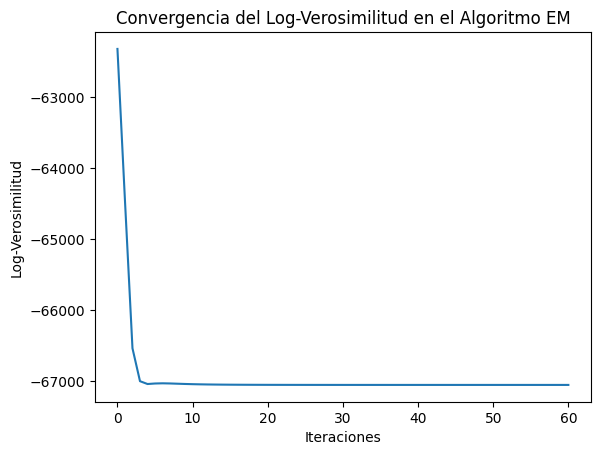

In [48]:
pi2_final, mu2_final, Sigma2_final, gamma2_final, log_likelihoods = expectation_maximization(X2_norm, mu2, Sigma2, pi2)

In [51]:
# Assign cluster labels based on maximum responsibility
Z2 = np.argmax(gamma2_final, axis=1)
df2['cluster'] = Z2
df2.head()

,balance,bonus_miles,bonus_trans,flight_trans_12,days_since_enroll,award?,cluster
0,28143,174,1,0,7000,0,0
1,19244,215,2,0,6968,0,0
2,41354,4123,4,0,7034,0,0
3,14776,500,1,0,6952,0,0
4,97752,43300,26,4,6935,1,0


Ahora agreguemos al dataframe original, una columna (`cluster`) con los valores determinados para la salida por el algoritmo.

In [67]:
df_airlines['cluster'] = df2['cluster']
# Conteo
df_comparacion = pd.DataFrame({'award?': df_airlines['award?'].value_counts(),
                               'cluster': df_airlines['cluster'].value_counts()})
df_comparacion

,award?,cluster
0,2518,3600
1,1481,399


La tabla anterior contiene la cantidad de valores esperados (`award?`) comparados por los valores que se asignaron por clusterización (`cluster`). De aqui podemos ver que **To Do...**

Graficamente podemos ver esto mediante el siguiente par de graficos de barra.

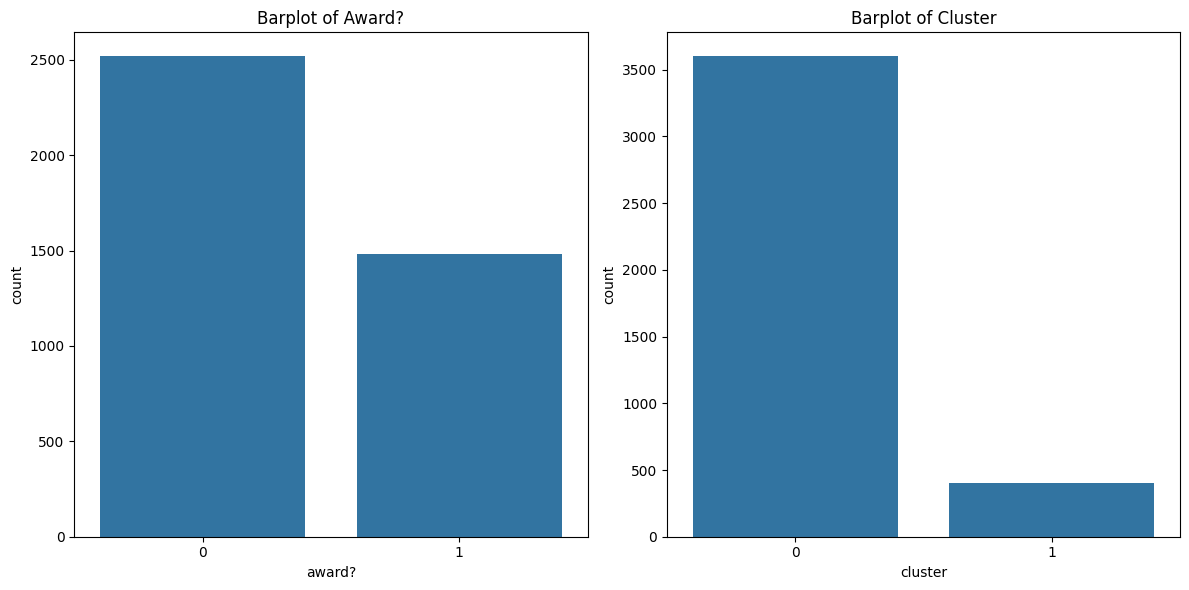

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_airlines is your DataFrame and it has columns 'aware?' and 'cluster'
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='award?', data=df_airlines)
plt.title('Barplot of Award?')

plt.subplot(1, 2, 2)
sns.countplot(x='cluster', data=df_airlines)
plt.title('Barplot of Cluster')

plt.tight_layout()
plt.show()


Ahora miremos el **rand index** comparando la salida esperada (`award?`) con la salida de los clusters (`cluster`)

In [69]:
rand_index = rand_score(df_airlines['award?'], df_airlines['cluster'])
print(f"Rand Index: {rand_index}")

Rand Index: 0.5660816154513866


El rand index es de 0.5660 lo cual explica que **To Do**....

In [79]:
df2.head()

,balance,bonus_miles,bonus_trans,flight_trans_12,days_since_enroll,award?,cluster
0,28143,174,1,0,7000,0,0
1,19244,215,2,0,6968,0,0
2,41354,4123,4,0,7034,0,0
3,14776,500,1,0,6952,0,0
4,97752,43300,26,4,6935,1,0


Finalmente, vamos a realizar el grafico pairplot usando las variables predictoras y segmentando respecto al cluster.

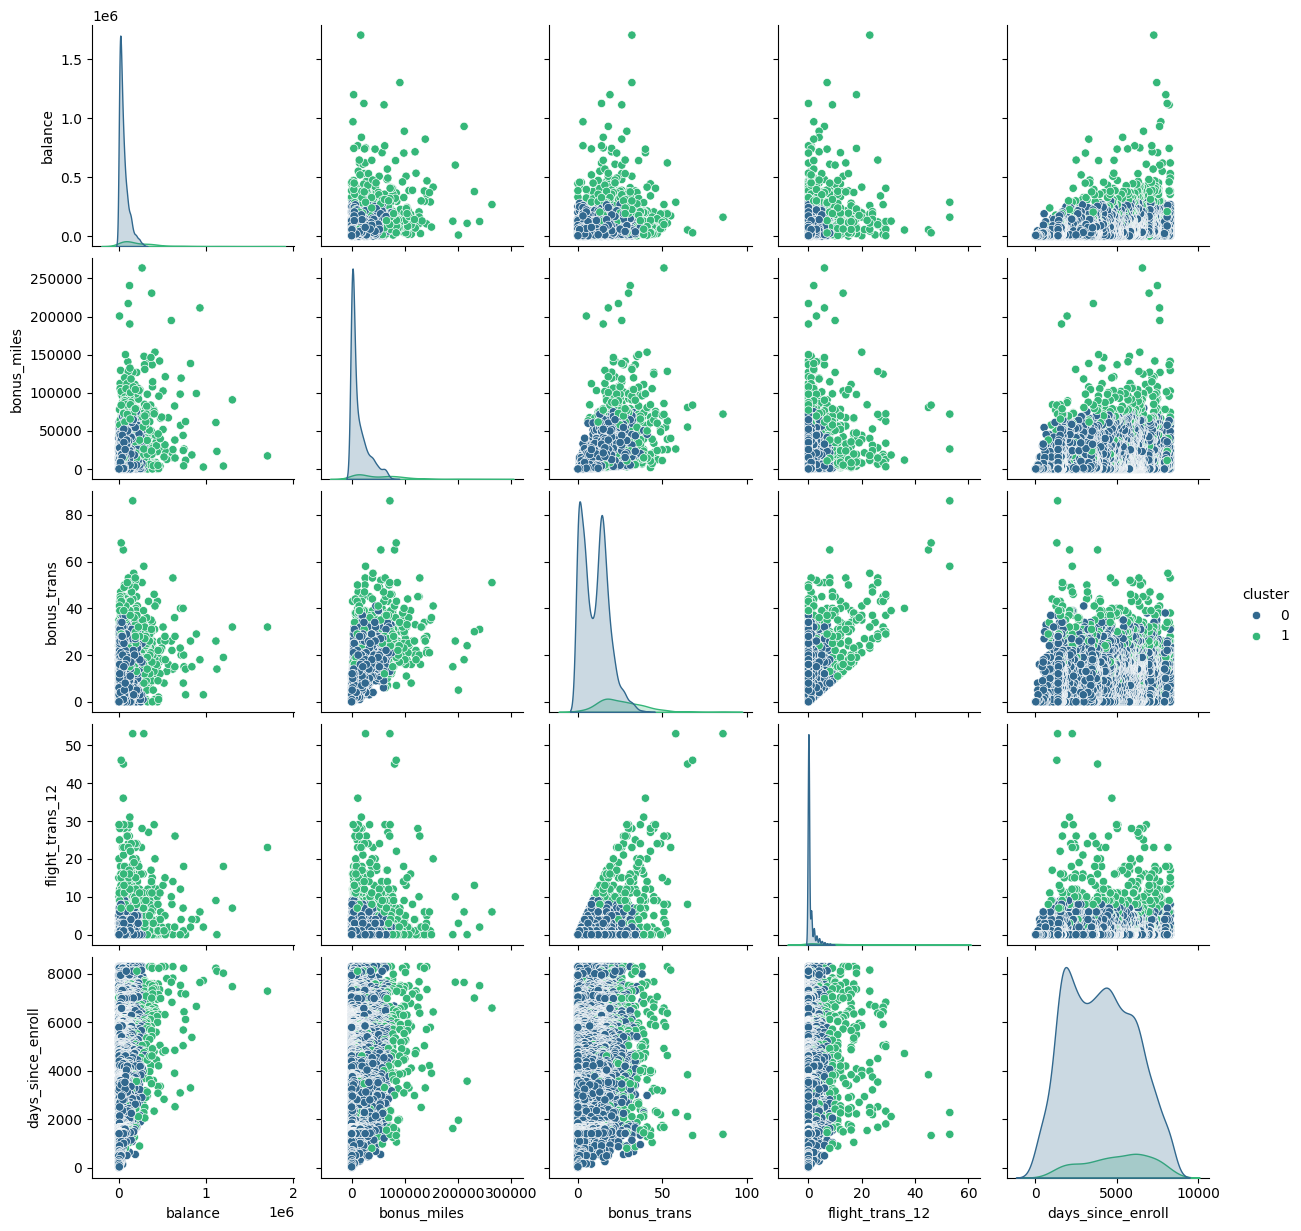

In [81]:
cols_to_plot = ['balance' , 'bonus_miles',	'bonus_trans', 'flight_trans_12', 'days_since_enroll',	'cluster']
sns.pairplot(df2[cols_to_plot], hue='cluster', palette = 'viridis')
plt.show()

In [84]:
# Agrupar por cluster y calcular estadísticas descriptivas
cluster_summary = df2[cols_to_plot].groupby('cluster').agg(['min', 'mean', 'max', 'std']).round(2)

# Mostrar la tabla
cluster_summary.T

cluster                         0           1
balance           min        0.00      231.00
                  mean   56718.81   225924.84
                  max   297127.00  1704838.00
                  std    54402.91   222293.35
bonus_miles       min        0.00        0.00
                  mean   13323.68    51621.50
                  max    79837.00   263685.00
                  std    16622.87    45129.72
bonus_trans       min        0.00        0.00
                  mean      10.09       25.20
                  max       41.00       86.00
                  std        7.87       12.68
flight_trans_12   min        0.00        0.00
                  mean       0.63        8.05
                  max        9.00       53.00
                  std        1.40        8.79
days_since_enroll min        2.00      798.00
                  mean    4022.15     4988.41
                  max     8296.00     8296.00
                  std     2050.18     1997.33

A continuación se muestran los graficos de cajas y bigotes para cada variable predictora respecto al cluster:

<ipython-input-93-66935eb190ab>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y = column, data = df_airlines, palette="coolwarm")
<ipython-input-93-66935eb190ab>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y = column, data = df_airlines, palette="coolwarm")
<ipython-input-93-66935eb190ab>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y = column, data = df_airlines, palette="coolwarm")
<ipython-input-93-66935eb190ab>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

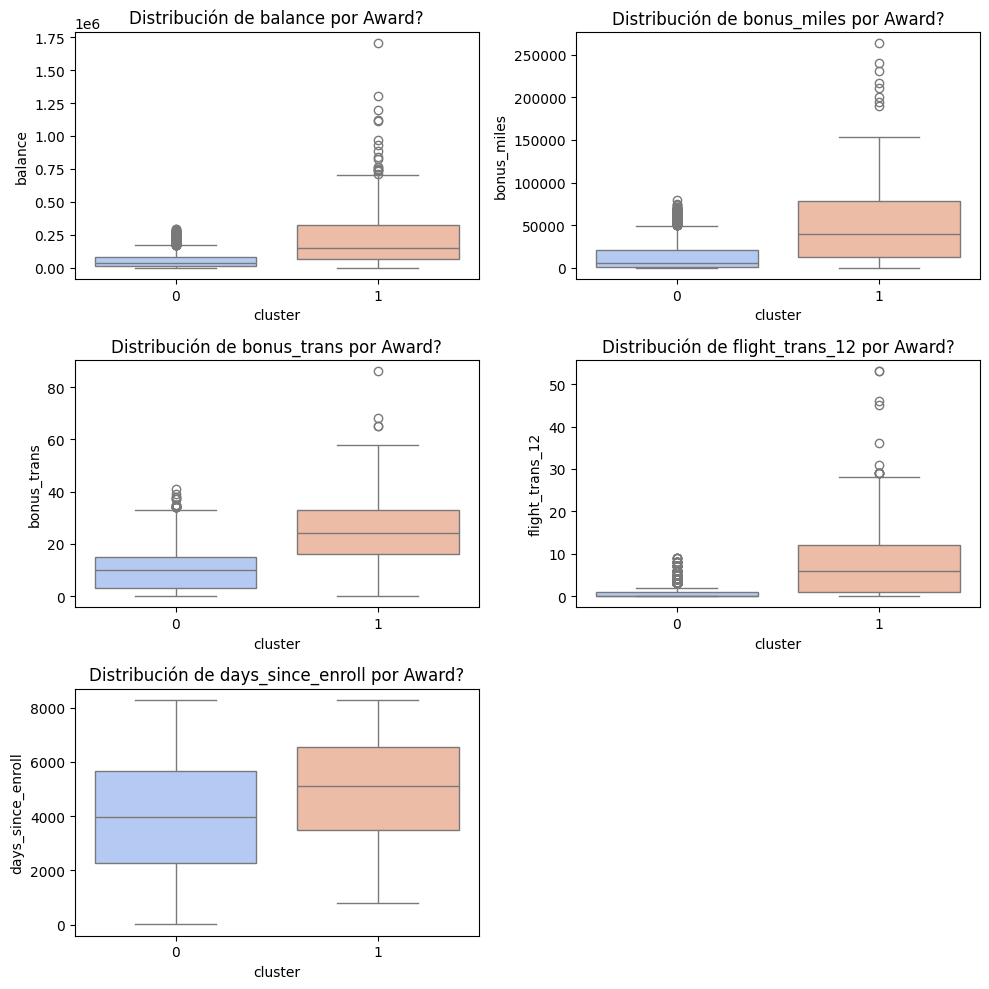

In [93]:
# Crear la figura con subgráficos (2 boxplots por columna)
plt.figure(figsize=(10, 10))

# Variables predictoras y la variable objetivo
variables_predictoras = ["balance", "bonus_miles", "bonus_trans", "flight_trans_12", "days_since_enroll"] # Corrected typo here

# Calcular el número de filas necesarias (2 gráficos por columna)
num_filas = (len(variables_predictoras) + 1) // 2

# Generar los boxplots
for i, column in enumerate(variables_predictoras, 1):
    plt.subplot(num_filas, 2, i)  # Configurar 2 gráficos por columna
    sns.boxplot(x="cluster", y = column, data = df_airlines, palette="coolwarm")
    plt.title(f"Distribución de {column} por Award?")

plt.tight_layout()
plt.show()

Podemos ver que **To Do...**

#### 4.3. Resultados y conclusiones

**To Do...**